# **Mestrado em Informática**
# **Pós-Graduação em Data Science and Digital Transformation**

## *(Ambientes de) Programação para Ciência de Dados*

**Mónica Vieira Martins**  
----

>#  Dados não balanceados


# Introdução:


# Dados

Neste tutorial vamos continuar a  utilizar um conjunto de dados referente aos passageiros do [Titanic](https://https://www.kaggle.com/c/titanic/data), para identificar a situação de dados não balanceados (ou desbalanceados) e prepará-los para análise futuras.

O ficheiro de dados denomina-se `Titanic.csv`. A descrição das colunas do ficheiro é a seguinte:

>Variável | Significado | Valores
>---------|-------------|---------
>Survival | sobrevivência | 0=Não, 1=Sim  |
>Pclass | classe do bilhete | 1=1ª, 2=2ª, 3=3ª|
> Name | nome | |
>Sex | sexo | male, female |
>Age | idade, em anos | |
>Sibsp | número de irmãos/esposos a bordo||
>Parch | número de pais/filhos a bordo |
>Ticket |	número do bilhete |
>Fare | preço pago  |
> Embarked | porto de embarcação | C=Cherbourg, Q=Queenstown, S=Southampton




In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")
import numpy as np


In [3]:
path = "titanic_preprocessado.csv"
df = pd.read_csv(path)

In [5]:
df.shape

(891, 8)

In [4]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'Sex', 'Embarked_1',
       'Embarked_0'],
      dtype='object')

In [6]:
df.describe()

,Survived,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208,0.904602,0.647587,0.086420,0.725028
std,0.486592,0.836071,13.002015,49.693429,1.613459,0.477990,0.281141,0.446751
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,7.910400,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,29.699118,14.454200,0.000000,1.000000,0.000000,1.000000
75%,1.000000,3.000000,35.000000,31.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,3.000000,80.000000,512.329200,10.000000,1.000000,1.000000,1.000000


# Distribuição da variável alvo


Começamos por verificar a frequência relativa dos valores da variável alvo, `Survived`

In [8]:
# Distribuição da variável Survived
freq = df["Survived"].value_counts()
freq_pct = df["Survived"].value_counts(normalize=True) * 100

print("Frequências absolutas:")
print(freq)
print("\nFrequências relativas (%):")
print(freq_pct.round(2))



Frequências absolutas:
Survived
0.0    549
1.0    342
Name: count, dtype: int64

Frequências relativas (%):
Survived
0.0    61.62
1.0    38.38
Name: proportion, dtype: float64


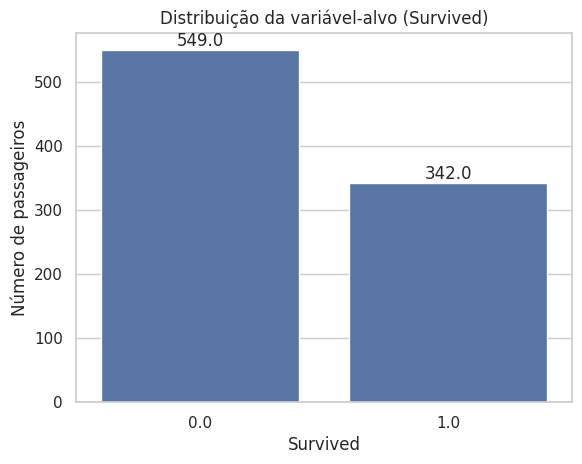

In [9]:
# Gráfico de barras
sns.set(style="whitegrid")
ax = sns.countplot(x="Survived", data=df)
ax.set_title("Distribuição da variável-alvo (Survived)")
ax.set_xlabel("Survived")
ax.set_ylabel("Número de passageiros")

# Mostrar valores em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom")

plt.show()

## Exemplo de *undersampling*

Usa-se o método df.sample(), que seleciona linhas aleatórias de um DataFrame,para obter uma amostragem aleatória.

In [33]:
# Identificar classe maioritária e minoritária
classe_maj = df["Survived"].value_counts().idxmax()
classe_min = df["Survived"].value_counts().idxmin()


n_min = df["Survived"].value_counts().min()

# Separar as duas classes
df_min = df[df["Survived"] == classe_min]
df_maj = df[df["Survived"] == classe_maj].sample(
    n=n_min, random_state=42
)

# Juntar para ter dataset balanceado por undersampling
df_under = pd.concat([df_min, df_maj], axis=0)



Comparemos o distribuição dos dados  depois da transformação

In [35]:
print("\nDistribuição após undersampling:")
print(df_under["Survived"].value_counts())
print("\nDistribuição após undersampling (%):")
print((df_under["Survived"].value_counts(normalize=True) * 100))


Distribuição após undersampling:
Survived
1.0    342
0.0    342
Name: count, dtype: int64

Distribuição após undersampling (%):
Survived
1.0    50.0
0.0    50.0
Name: proportion, dtype: float64


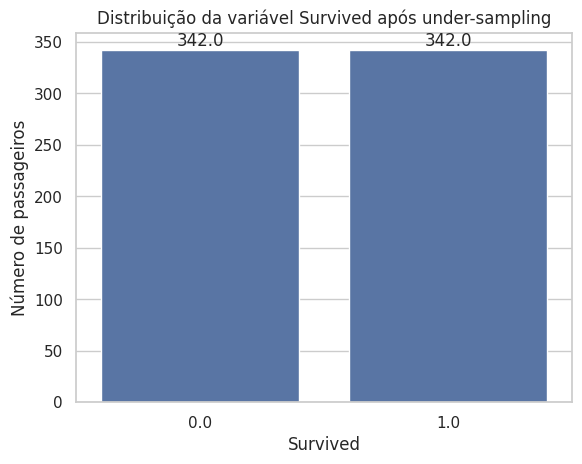

In [14]:
# Gráfico de barras
sns.set(style="whitegrid")
ax = sns.countplot(x="Survived", data=df_under)
ax.set_title("Distribuição da variável Survived após under-sampling")
ax.set_xlabel("Survived")
ax.set_ylabel("Número de passageiros")

# Mostrar valores em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height}", (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom")

plt.show()

## Exemplo de oversampling (duplicação de linhas)


In [21]:
train_over = df_min.copy()  # começar pela classe minoritária
#df_min já está definifo.
#voltamos a definir df_max
df_min = df[df["Survived"] == classe_min]
df_maj = df[df["Survived"] == classe_maj]
# Quantos exemplos precisamos acrescentar para igualar a classe maior?
n_to_add = len(df_maj) - len(df_min)

df_min_extra = df_min.sample(n=n_to_add, replace=True, random_state=42)

df_over = pd.concat([train_over, df_min_extra, df_maj], axis=0)

In [22]:
print("\nDistribuição após oversampling:")
print(df_over["Survived"].value_counts())
print("\nDistribuição após oversampling (%):")
print((df_over["Survived"].value_counts(normalize=True) * 100).round(2))


Distribuição após oversampling:
Survived
1.0    549
0.0    549
Name: count, dtype: int64

Distribuição após oversampling (%):
Survived
1.0    50.0
0.0    50.0
Name: proportion, dtype: float64


As proporções ficam equilibradas, mas há muitas linhas repetidas.
A amostra aparenta ser maior, mas não há  informação .

## SMOTE (Syntethic Minority Oversampling Technique)

In [ ]:
!pip install imbalanced-learn

In [24]:
from imblearn.over_sampling import SMOTE

# Define features (X) and target (y)
X = df.drop("Survived", axis=1)
y = df["Survived"]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("\nDistribuição após SMOTE:")
print(y_res.value_counts())
print("\nDistribuição após SMOTE (%):")
print((y_res.value_counts(normalize=True) * 100).round(2))


Distribuição após SMOTE:
Survived
0.0    549
1.0    549
Name: count, dtype: int64

Distribuição após SMOTE (%):
Survived
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64


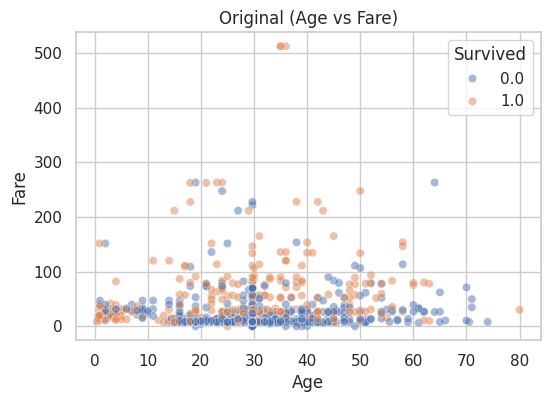

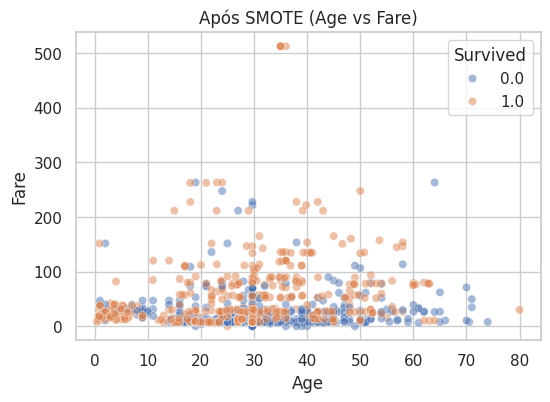

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico original
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X["Age"], y=X["Fare"], hue=y, alpha=0.5)
plt.title("Original (Age vs Fare)")
plt.show()

# Gráfico após SMOTE
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_res["Age"], y=X_res["Fare"], hue=y_res, alpha=0.5)
plt.title("Após SMOTE (Age vs Fare)")
plt.show()

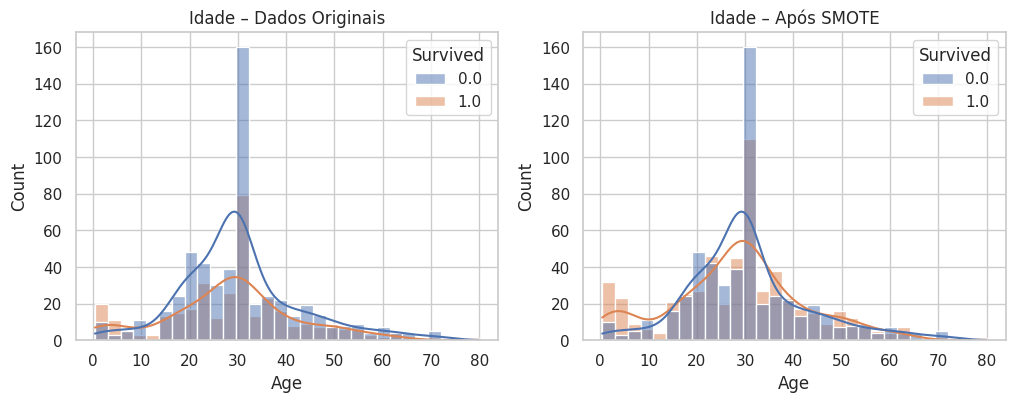

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Idade – Dados Originais")

temp_df_smote = pd.DataFrame({'Age': X_res["Age"], 'Survived': y_res})
sns.histplot(data=temp_df_smote, x="Age", hue="Survived", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Idade – Após SMOTE")

plt.show()

Verifiquemos onde são criados os pontos sintétivos, usando como exemplo "Age" e "Fare"

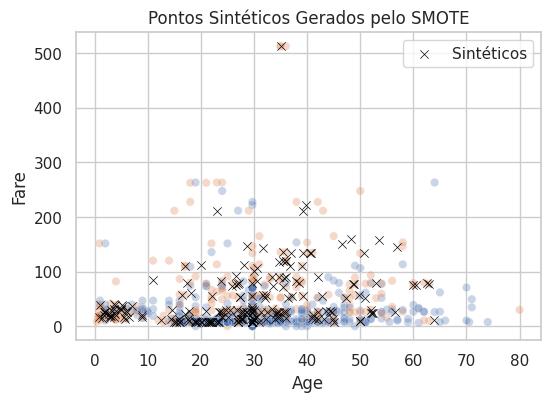

In [30]:
n_original = len(X)
X_sint = X_res.iloc[n_original:]
y_sint = y_res.iloc[n_original:]

plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=X["Age"], y=X["Fare"],
    hue=y, alpha=0.3, legend=False
)
sns.scatterplot(
    x=X_sint["Age"], y=X_sint["Fare"],
    color="black", marker="x", label="Sintéticos"
)
plt.title("Pontos Sintéticos Gerados pelo SMOTE")
plt.legend()
plt.show()

O SMOTE não cria valores extremos; antes, preenche zonas existentes. Isto é, altera a quantidade de observações, mas não o intervalo dos dados.

Podemos também verificar que as distribuição estatisitca se mantém. No exemplo seguinte verificamos as alteraçãoe insignificatnes no valos médio das vairávei numéricas.  

In [32]:
stats_original = X.assign(Survived=y).groupby("Survived").mean()
stats_smote = X_res.assign(Survived=y_res).groupby("Survived").mean()
df_diff = (stats_smote - stats_original).round(2)

df_diff


,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
Survived,,,,,,,
0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00
1.0,-0.01,-0.16,-0.68,0.02,0.0,-0.01,0.02
